In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nehalbirla/vehicle-dataset-from-cardekho/car data.csv
/kaggle/input/datasets/nehalbirla/vehicle-dataset-from-cardekho/car details v4.csv
/kaggle/input/datasets/nehalbirla/vehicle-dataset-from-cardekho/CAR DETAILS FROM CAR DEKHO.csv
/kaggle/input/datasets/nehalbirla/vehicle-dataset-from-cardekho/Car details v3.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/kaggle/input/datasets/nehalbirla/vehicle-dataset-from-cardekho/car data.csv')

In [4]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
df.shape

(301, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [7]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [8]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(2)

In [10]:
df = df.drop_duplicates()

In [11]:
print("New shape after dropping duplicates:", df.shape)

New shape after dropping duplicates: (299, 9)


In [12]:
df = df.drop(['Car_Name'], axis=1)

In [13]:
df = pd.get_dummies(df, drop_first=True)

In [14]:
df.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,0,False,True,False,True
1,2013,4.75,9.54,43000,0,True,False,False,True
2,2017,7.25,9.85,6900,0,False,True,False,True
3,2011,2.85,4.15,5200,0,False,True,False,True
4,2014,4.60,6.87,42450,0,True,False,False,True


In [15]:
x = df.drop(["Selling_Price"], axis = 1)
y = df["Selling_Price"]

In [16]:
x

,Year,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,2014,5.59,27000,0,False,True,False,True
1,2013,9.54,43000,0,True,False,False,True
2,2017,9.85,6900,0,False,True,False,True
3,2011,4.15,5200,0,False,True,False,True
4,2014,6.87,42450,0,True,False,False,True
...,...,...,...,...,...,...,...,...
296,2016,11.60,33988,0,True,False,False,True
297,2015,5.90,60000,0,False,True,False,True
298,2009,11.00,87934,0,False,True,False,True
299,2017,12.50,9000,0,True,False,False,True


In [17]:
y

0       3.35
1       4.75
2       7.25
3       2.85
4       4.60
       ...  
296     9.50
297     4.00
298     3.35
299    11.50
300     5.30
Name: Selling_Price, Length: 299, dtype: float64

In [18]:
from sklearn.model_selection import train_test_split
x_train , x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)

In [19]:
x_train.shape

(239, 8)

In [20]:
x_test.shape

(60, 8)

In [21]:
from sklearn.linear_model import LinearRegression

In [22]:
lr = LinearRegression()

In [23]:
lr.fit(x_train, y_train)

LinearRegression()

In [24]:
from sklearn.metrics import mean_absolute_error, r2_score

In [25]:
y_pred = lr.predict(x_test)

In [26]:
y_pred

array([ 7.50192151,  7.79152142,  1.36644388,  7.00941894, 11.16328988,
        4.53410247,  8.49246345,  1.70078181,  8.82421963, -0.96348801,
       10.31444007, -0.97386896,  0.71832735,  1.53711566,  4.97622203,
        5.04627395,  1.29503012,  1.85159301, 21.56570817,  0.86767992,
        0.93078859,  2.45202839,  5.58169747,  0.2581242 ,  6.26649907,
        7.82350038,  8.68226641,  1.1746619 ,  4.84357381,  4.92069701,
        3.26811058,  5.48959967,  6.27470319,  2.75388094,  2.90385159,
        6.96790194,  1.26406586, -4.97141242,  1.38043678, 10.38468561,
        7.10536052,  9.04017934,  1.62741133,  4.01521109,  0.97463542,
       -2.14675103,  8.1451697 ,  4.37395524,  5.64880685, -0.59577608,
        0.66072164,  0.20325682, 10.20766115,  9.45415687,  7.29949412,
        6.25536738,  3.71408634,  3.43110175,  9.56341995,  9.1600735 ])

In [27]:
r2 = r2_score(y_test, y_pred)

In [28]:
r2

0.7528154215831643

In [29]:
mae = mean_absolute_error(y_test, y_pred)

In [30]:
mae

1.472892414003326

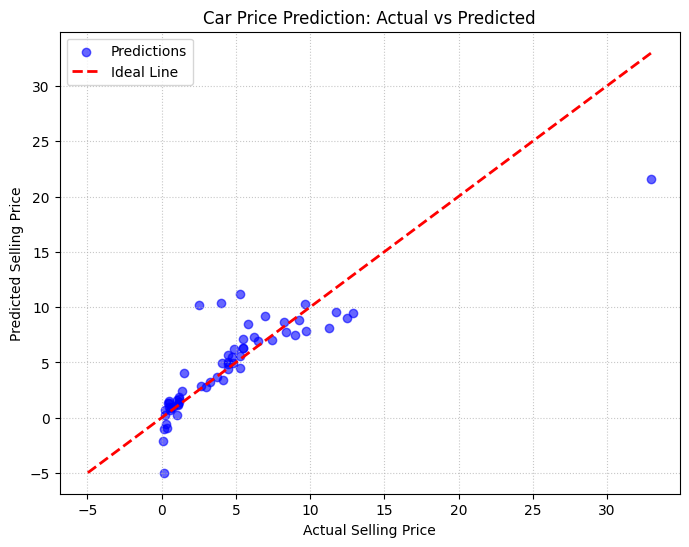

In [31]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label='Predictions')
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Line')

plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Car Price Prediction: Actual vs Predicted')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()